# TriWeb ML API — Comparaison de modèles + déploiement professionnel

Objectif du notebook :

1. Charger les données TriWeb depuis l’API ou un CSV local.
2. Préparer les variables métier : dates, états R/G, teams, loi Hamon, charge, affectation.
3. Construire trois modules ML :
   - **Prédiction des retards**
   - **Estimation de surcharge / charge restante**
   - **Score d’affectation**
4. Comparer plusieurs modèles pour chaque module.
5. Sélectionner automatiquement le meilleur modèle.
6. Sauvegarder les modèles entraînés.
7. Générer une API FastAPI de déploiement.
8. Générer une interface Streamlit avec des champs à remplir pour tester les prédictions.

> Ce notebook est pensé pour un usage production manager : résultats explicables, comparaisons visibles, déploiement simple.


## 0. Installation optionnelle

In [8]:
# Décommente si une librairie manque dans ton environnement.
# !pip install pandas numpy requests scikit-learn matplotlib joblib fastapi uvicorn streamlit pydantic

## 1. Imports et configuration

In [9]:
import os
import re
import json
import math
import warnings
import unicodedata
from pathlib import Path
from datetime import datetime, date

import numpy as np
import pandas as pd
import requests
import joblib
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "models"
DEPLOY_DIR = BASE_DIR / "deployment"
MODELS_DIR.mkdir(exist_ok=True)
DEPLOY_DIR.mkdir(exist_ok=True)

API_URL = os.getenv(
    "TRIWEB_API_URL",
    "https://tools.triweb-apps.com/Triweb_NewV/intern/api/VDbPlanificationMaj"
)

# Option : si l’API ne répond pas, placer un CSV ici.
LOCAL_CSV = BASE_DIR / "triweb_raw_api.csv"

RANDOM_STATE = 42
REFERENCE_DATE = pd.Timestamp.today().normalize()
CAPACITE_JOUR_MINUTES = 480

print("BASE_DIR:", BASE_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("DEPLOY_DIR:", DEPLOY_DIR)
print("REFERENCE_DATE:", REFERENCE_DATE.date())

from sklearn.base import clone


BASE_DIR: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api
MODELS_DIR: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models
DEPLOY_DIR: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\deployment
REFERENCE_DATE: 2026-05-20


## 2. Fonctions utilitaires

In [10]:
def log(title: str):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)

def norm_txt(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def safe_series(df: pd.DataFrame, col: str, default=""):
    if col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index)

def safe_numeric(x, default=0):
    try:
        return float(x)
    except Exception:
        return default

def duration_to_minutes(value) -> float:
    if pd.isna(value):
        return 0.0
    text = str(value).strip()
    if not text:
        return 0.0
    m = re.match(r"^(\d+):(\d+):(\d+)$", text)
    if m:
        h, mi, s = map(int, m.groups())
        return h * 60 + mi + s / 60
    m = re.match(r"^(\d+):(\d+)$", text)
    if m:
        mi, s = map(int, m.groups())
        return mi + s / 60
    try:
        return float(text)
    except Exception:
        return 0.0

def parse_triweb_date(value, fallback_year=None):
    if pd.isna(value):
        return pd.NaT
    raw = str(value).strip()
    if not raw:
        return pd.NaT

    # ISO ou date standard
    direct = pd.to_datetime(raw, errors="coerce", dayfirst=True)
    if pd.notna(direct):
        return direct.normalize()

    year = int(fallback_year) if fallback_year and str(fallback_year).strip() else REFERENCE_DATE.year

    # dd/mm
    m = re.match(r"^(\d{1,2})[\/\-\.](\d{1,2})$", raw)
    if m:
        d, mo = map(int, m.groups())
        try:
            return pd.Timestamp(year=year, month=mo, day=d)
        except Exception:
            return pd.NaT

    # dd/mm/yyyy
    m = re.match(r"^(\d{1,2})[\/\-\.](\d{1,2})[\/\-\.](\d{2,4})$", raw)
    if m:
        d, mo, y = m.groups()
        y = int(y)
        if y < 100:
            y += 2000
        try:
            return pd.Timestamp(year=y, month=int(mo), day=int(d))
        except Exception:
            return pd.NaT

    return pd.NaT

def is_status(value, key: str) -> bool:
    n = norm_txt(value)
    return key in n

def is_finished(value) -> bool:
    n = norm_txt(value)
    return any(k in n for k in ["valide", "termine", "livre"])

def is_en_cours(value) -> bool:
    return "en cours" in norm_txt(value)

def is_affecte(value) -> bool:
    return "affect" in norm_txt(value)

def is_pause(value) -> bool:
    return "pause" in norm_txt(value)

def is_retour_cq(value) -> bool:
    n = norm_txt(value)
    return "retour cq" in n or n == "retour" or "non conforme" in n

def loi_type(value) -> str:
    n = norm_txt(value)
    if n.startswith("1") or "production standard" in n:
        return "production_standard"
    if n.startswith("2") or "refonte avec redaction" in n:
        return "refonte_avec_redaction"
    if n.startswith("3") or "refonte sans redaction" in n or "sans redaction" in n:
        return "refonte_sans_redaction"
    if n.startswith("4") or "ticket modification" in n or "ticket" in n:
        return "ticket_modification"
    return "autre"

def clean_position(value) -> str:
    n = norm_txt(value)
    if "production" in n:
        return "Production"
    if "cq client" in n:
        return "CQ Client"
    if "cq interne" in n:
        return "CQ Interne"
    if n == "client" or "client" in n:
        return "Client"
    if "ftp" in n:
        return "FTP"
    if "archive" in n:
        return "Archive"
    return str(value).strip() if not pd.isna(value) else ""


## 3. Chargement des données TriWeb

In [11]:
def load_triweb_data() -> pd.DataFrame:
    try:
        log("Chargement API TriWeb")
        response = requests.get(API_URL, timeout=120, verify=False)
        response.raise_for_status()
        payload = response.json()

        if isinstance(payload, list):
            data = payload
        elif isinstance(payload, dict):
            data = None
            for key in ["items", "data", "result", "results", "rows", "value"]:
                if key in payload and isinstance(payload[key], list):
                    data = payload[key]
                    break
            if data is None:
                data = [payload]
        else:
            raise ValueError("Format API non reconnu")

        df = pd.json_normalize(data)
        df.to_csv(LOCAL_CSV, index=False, encoding="utf-8-sig")
        print("API OK:", len(df), "lignes")
        return df

    except Exception as ex:
        print("API inaccessible, fallback CSV:", ex)
        if LOCAL_CSV.exists():
            df = pd.read_csv(LOCAL_CSV)
            print("CSV local OK:", len(df), "lignes")
            return df
        raise

df_raw = load_triweb_data()
display(df_raw.head())
print("Colonnes:", list(df_raw.columns)[:50])



Chargement API TriWeb
API OK: 534 lignes


,loiHamon,livraison,planProd,planR,planG,planCqi,planCqc,id,type,estimation,...,finCqi,debutCqc,finCqc,priorite,prioriteR,prioriteG,prioriteCqi,infirmerie,sansCq,detail
0,1- Production Standard,Client,Client,,,,,135479,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,NaN,NaN,NaN,False,0,28/05 -> 18/05 - Client - Site - LocalVisibili...
1,1- Production Standard,Client,Client,En instance,En instance,En instance,,134725,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,18/05 -> 05/05 - Client - Site - LocalVisibili...
2,1- Production Standard,Client,Client,En instance,En instance,En instance,,135213,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,22/05 -> 12/05 - Client - Site - LocalBoutique...
3,1- Production Standard,Client,Client,Finalisé,Affecté,En instance,,129029,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,24/02 -> 02/02 - Client - Site - LocalVisibili...
4,1- Production Standard,Client,Client,Validé,En instance,En instance,,135320,0,480,...,1900-01-01T00:00:00,1900-01-01T00:00:00,1900-01-01T00:00:00,0,-1.0,-1.0,-1.0,False,0,26/05 -> 13/05 - Client - Site - LocalTaxiVTC ...


Colonnes: ['loiHamon', 'livraison', 'planProd', 'planR', 'planG', 'planCqi', 'planCqc', 'id', 'type', 'estimation', 'nature', 'p', 'pr', 'pg', 'pq', 'dateLivraisonPrevue', 'dateLivraison', 'postion', 'statut', 'etatR', 'etatG', 'etatCqi', 'etatCqc', 'dureeR', 'dureeG', 'dureeCqi', 'dureeCqc', 'teamR', 'teamG', 'redacteur', 'graphiste', 'cqinterne', 'cqclient', 'mois', 'annee', 'dateReception', 'codeClient', 'rs', 'page', 'debutR', 'finR', 'debutG', 'finG', 'debutCqi', 'finCqi', 'debutCqc', 'finCqc', 'priorite', 'prioriteR', 'prioriteG']


## 4. Mapping et nettoyage métier

In [12]:
def build_dataset(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    out["id_dossier"] = safe_series(df, "id", df.index).astype(str)
    out["code_client"] = safe_series(df, "codeClient", "").astype(str)
    out["client"] = safe_series(df, "rs", "").astype(str).str.strip()

    out["position_raw"] = safe_series(df, "postion", safe_series(df, "position", "")).astype(str)
    out["position"] = out["position_raw"].apply(clean_position)

    out["statut"] = safe_series(df, "statut", "").astype(str)
    out["loi_hamon"] = safe_series(df, "loiHamon", "").astype(str)
    out["loi_type"] = out["loi_hamon"].apply(loi_type)
    out["nature"] = safe_series(df, "nature", "").astype(str)

    out["etatR"] = safe_series(df, "etatR", "").astype(str)
    out["etatG"] = safe_series(df, "etatG", "").astype(str)
    out["etatCqi"] = safe_series(df, "etatCqi", "").astype(str)
    out["etatCqc"] = safe_series(df, "etatCqc", "").astype(str)

    out["teamR"] = safe_series(df, "teamR", "").astype(str)
    out["teamG"] = safe_series(df, "teamG", "").astype(str)
    out["redacteur"] = safe_series(df, "redacteur", "").astype(str)
    out["graphiste"] = safe_series(df, "graphiste", "").astype(str)

    out["page"] = pd.to_numeric(safe_series(df, "page", 0), errors="coerce").fillna(0)
    out["charge"] = pd.to_numeric(safe_series(df, "charge", 0), errors="coerce").fillna(0)
    out["totalHours"] = pd.to_numeric(safe_series(df, "totalHours", 0), errors="coerce").fillna(0)

    out["dureeR_min"] = safe_series(df, "dureeR", "").apply(duration_to_minutes)
    out["dureeG_min"] = safe_series(df, "dureeG", "").apply(duration_to_minutes)
    out["dureeCqi_min"] = safe_series(df, "dureeCqi", "").apply(duration_to_minutes)
    out["dureeCqc_min"] = safe_series(df, "dureeCqc", "").apply(duration_to_minutes)

    out["annee"] = pd.to_numeric(safe_series(df, "annee", REFERENCE_DATE.year), errors="coerce").fillna(REFERENCE_DATE.year).astype(int)

    out["date_reception"] = [
        parse_triweb_date(v, y) for v, y in zip(safe_series(df, "dateReception", ""), out["annee"])
    ]
    out["date_livraison_prevue"] = [
        parse_triweb_date(v, y) for v, y in zip(safe_series(df, "dateLivraisonPrevue", ""), out["annee"])
    ]
    out["date_livraison"] = [
        parse_triweb_date(v, y) for v, y in zip(safe_series(df, "dateLivraison", ""), out["annee"])
    ]

    out["jours_restants"] = (out["date_livraison_prevue"] - REFERENCE_DATE).dt.days
    out["jours_restants"] = out["jours_restants"].fillna(999).astype(float)

    for col in ["etatR", "etatG", "etatCqi", "etatCqc", "statut", "position", "teamR", "teamG"]:
        out[col + "_norm"] = out[col].apply(norm_txt)

    return out

df = build_dataset(df_raw)
display(df.head())
df.to_csv(MODELS_DIR / "triweb_clean_dataset.csv", index=False, encoding="utf-8-sig")
print("Dataset nettoyé:", df.shape)


,id_dossier,code_client,client,position_raw,position,statut,loi_hamon,loi_type,nature,etatR,...,date_livraison,jours_restants,etatR_norm,etatG_norm,etatCqi_norm,etatCqc_norm,statut_norm,position_norm,teamR_norm,teamG_norm
0,135479,628491,MENUISERIE VERNET,Client,Client,En instance,1- Production Standard,production_standard,Site - LocalVisibilité,,...,NaT,8.0,,,,,en instance,client,en instance client,en instance client
1,134725,608729,AU SALON ENCHAN'THE,Client,Client,En instance,1- Production Standard,production_standard,Site - LocalVisibilité,En instance,...,NaT,-2.0,en instance,en instance,en instance,,en instance,client,en instance client,en instance client
2,135213,622585,PHENIX ADAM,Client,Client,En instance,1- Production Standard,production_standard,Site - LocalBoutique Webtool,En instance,...,NaT,2.0,en instance,en instance,en instance,,en instance,client,en instance client,en instance client
3,129029,598407,AUTOUR DE VOUS,Client,Client,En instance,1- Production Standard,production_standard,Site - LocalVisibilité,Finalisé,...,NaT,-85.0,finalise,affecte,en instance,,en instance,client,en instance client,en instance client
4,135320,627422,DRIVER KA,Client,Client,En instance,1- Production Standard,production_standard,Site - LocalTaxiVTC,Validé,...,NaT,6.0,valide,en instance,en instance,,en instance,client,en instance client,en instance client


Dataset nettoyé: (534, 37)


## 5. Construction des cibles métier supervisées

Si on n’a pas encore de labels historiques, on crée des cibles métier fiables à partir des règles TriWeb. Ensuite les modèles apprennent ces décisions et permettent la prédiction sur de nouveaux dossiers.

In [13]:
def compute_retard_label(row) -> int:
    # Retard / risque élevé = 1 ; sinon 0
    position = norm_txt(row["position"])
    statut = norm_txt(row["statut"])
    jours = float(row["jours_restants"])
    etatR = row["etatR_norm"]
    etatG = row["etatG_norm"]
    loi = row["loi_type"]

    if statut in ["livre", "livré", "valide", "validé"]:
        return 0

    if position != "production":
        return 0

    if pd.notna(row["date_livraison_prevue"]) and jours < 0:
        return 1

    if loi == "production_standard":
        # J : R et G doivent être validés
        if jours <= 0:
            if "valide" not in etatR:
                return 1
            if "valide" not in etatG and ("affect" in etatG or "en cours" in etatG or "pause" in etatG):
                return 1
        # J+1 : R doit être validé
        if jours == 1 and "valide" not in etatR:
            return 1

    # Retours / pause proches livraison
    if jours <= 1 and (is_pause(row["etatR"]) or is_pause(row["etatG"])):
        return 1

    return 0

def estimate_charge_remaining(row) -> float:
    pages = float(row["page"] or 0)
    loi = row["loi_type"]

    if loi == "ticket_modification":
        base_redac = 0
        base_graph = 90
    elif loi == "refonte_sans_redaction":
        base_redac = 0
        base_graph = 480
    elif loi == "refonte_avec_redaction":
        base_redac = 960
        base_graph = 480
    else:
        base_redac = 960
        base_graph = 480

    if pages > 5:
        base_redac += max(pages - 5, 0) * 25
        base_graph += max(pages - 5, 0) * 20

    if is_finished(row["etatR"]):
        base_redac = 0

    if is_finished(row["etatG"]):
        base_graph = 0

    remaining = max(base_redac - row["dureeR_min"], 0) + max(base_graph - row["dureeG_min"], 0)

    return float(np.clip(remaining, 0, 1440))

def compute_affectation_score(row) -> float:
    # Score de qualité d’affectation : 0 à 100.
    score = 50.0

    position = norm_txt(row["position"])
    etatR = row["etatR_norm"]
    etatG = row["etatG_norm"]
    teamR = row["teamR_norm"]
    teamG = row["teamG_norm"]

    if position == "production":
        score += 10

    # Affectation réelle
    if row["redacteur"].strip() and "non affecte" not in norm_txt(row["redacteur"]):
        score += 12
    if row["graphiste"].strip() and "non affecte" not in norm_txt(row["graphiste"]):
        score += 12

    if "affect" in etatR or "en cours" in etatR:
        score += 8
    if "affect" in etatG or "en cours" in etatG:
        score += 8

    # Non affectation détectée selon règles métier
    teamR_non_aff = any(x in teamR for x in [
        "production : non affecte", "cq interne : non affecte", "ftp : non affecte",
        "archive : non affecte", "cq client : non affecte"
    ])
    teamG_non_aff = "cdc - en cours" in teamG

    if teamR_non_aff:
        score -= 25
    if teamG_non_aff:
        score -= 25

    if is_retour_cq(row["etatR"]) or is_retour_cq(row["etatG"]):
        score -= 10

    return float(np.clip(score, 0, 100))

df["target_retard"] = df.apply(compute_retard_label, axis=1)
df["target_charge_minutes"] = df.apply(estimate_charge_remaining, axis=1)
df["target_charge_hours"] = df["target_charge_minutes"] / 60
df["target_affectation_score"] = df.apply(compute_affectation_score, axis=1)

display(df[[
    "id_dossier", "client", "position", "statut", "loi_type", "etatR", "etatG",
    "jours_restants", "target_retard", "target_charge_hours", "target_affectation_score"
]].head(10))

print("Retard distribution:")
display(df["target_retard"].value_counts(dropna=False))


,id_dossier,client,position,statut,loi_type,etatR,etatG,jours_restants,target_retard,target_charge_hours,target_affectation_score
0,135479,MENUISERIE VERNET,Client,En instance,production_standard,,,8.0,0,24.000000,50.0
1,134725,AU SALON ENCHAN'THE,Client,En instance,production_standard,En instance,En instance,-2.0,0,24.000000,50.0
2,135213,PHENIX ADAM,Client,En instance,production_standard,En instance,En instance,2.0,0,24.000000,50.0
3,129029,AUTOUR DE VOUS,Client,En instance,production_standard,Finalisé,Affecté,-85.0,0,22.374444,82.0
4,135320,DRIVER KA,Client,En instance,production_standard,Validé,En instance,6.0,0,8.000000,62.0
5,134745,LA FORGE,CQ Client,Retour CQ traité,production_standard,Retour CQ traité,Retour CQ traité,-2.0,0,13.023333,64.0
6,134635,NETTOYAGE SIGNATURE,CQ Client,Retour CQ traité,production_standard,Retour CQ traité,Retour CQ traité,-5.0,0,11.493333,64.0
7,134691,BODY LUMIÉRE,CQ Client,Non Conforme,production_standard,Retour CQ traité,En pause,-2.0,0,13.869444,64.0
8,134547,RESTO OPALE PIZZA,CQ Client,Non Conforme,production_standard,Retour CQ traité,Retour CQ,-7.0,0,13.538611,64.0
9,134629,RM SERVICE+,Archive,Validé client,production_standard,Retour CQ traité,Retour CQ traité,-5.0,0,12.973611,64.0


Retard distribution:


target_retard
0    513
1     21
Name: count, dtype: int64

## 6. Features utilisées par les modèles

In [14]:
FEATURES = [
    "position", "statut", "loi_type", "nature",
    "etatR", "etatG", "etatCqi", "etatCqc",
    "teamR", "teamG",
    "page", "charge", "totalHours",
    "dureeR_min", "dureeG_min", "dureeCqi_min", "dureeCqc_min",
    "jours_restants"
]

categorical_features = [
    "position", "statut", "loi_type", "nature",
    "etatR", "etatG", "etatCqi", "etatCqc",
    "teamR", "teamG"
]

numeric_features = [
    "page", "charge", "totalHours",
    "dureeR_min", "dureeG_min", "dureeCqi_min", "dureeCqc_min",
    "jours_restants"
]

def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

X = df[FEATURES].copy()

print("Features:", FEATURES)

Features: ['position', 'statut', 'loi_type', 'nature', 'etatR', 'etatG', 'etatCqi', 'etatCqc', 'teamR', 'teamG', 'page', 'charge', 'totalHours', 'dureeR_min', 'dureeG_min', 'dureeCqi_min', 'dureeCqc_min', 'jours_restants']


## 7. Module 1 — Comparaison modèles : prédiction des retards

In [15]:
def compare_classification_models(X, y):
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    }

    stratify = y if y.nunique() > 1 and y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=stratify
    )

    results = []
    fitted = {}

    for name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", build_preprocessor()),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_test)

        try:
            proba = pipe.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else np.nan
        except Exception:
            auc = np.nan

        results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": auc
        })

        fitted[name] = pipe

    res = pd.DataFrame(results).sort_values(
        ["f1", "roc_auc", "accuracy"],
        ascending=False
    )

    best_name = res.iloc[0]["model"]
    best_model = fitted[best_name]

    return res, best_name, best_model, (X_test, y_test)


retard_results, best_retard_name, best_retard_model, retard_test = compare_classification_models(
    X[FEATURES].copy(),
    df["target_retard"].copy()
)

display(retard_results)
print("Meilleur modèle retard:", best_retard_name)

joblib.dump(best_retard_model, MODELS_DIR / "best_retard_model.joblib")


,model,accuracy,f1,roc_auc
0,Logistic Regression,0.992537,0.888889,0.961240
2,Gradient Boosting,0.992537,0.888889,0.900775
1,Random Forest,0.985075,0.750000,0.994574


Meilleur modèle retard: Logistic Regression


['c:\\Users\\marie\\Downloads\\triweb1\\triweb\\backend\\AI\\ml-api\\models\\best_retard_model.joblib']

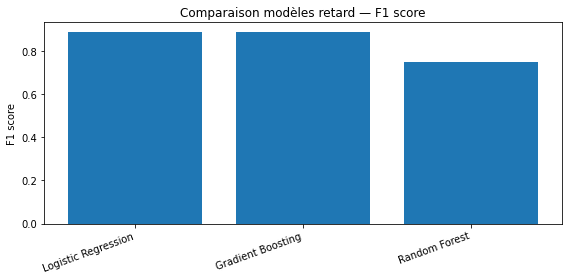

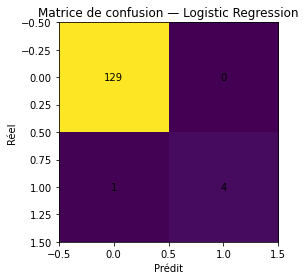

In [16]:
# Visualisation comparaison retard
plt.figure(figsize=(8, 4))
plt.bar(retard_results["model"], retard_results["f1"])
plt.title("Comparaison modèles retard — F1 score")
plt.ylabel("F1 score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

X_test, y_test = retard_test
pred = best_retard_model.predict(X_test)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Matrice de confusion — {best_retard_name}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()


## 8. Module 2 — Comparaison modèles : estimation de surcharge / charge restante

In [17]:
# ============================================================
# FORMULE METIER - CHARGE TOTALE / CHARGE RESTANTE / SURCHARGE
# A placer AVANT compare_regression_models(X, y)
# ============================================================

CAPACITE_JOUR_MINUTES = 480  # 8h par jour

def is_state_validated(value) -> bool:
    n = norm_txt(value)
    return "valide" in n or "validé" in n or "livre" in n or "livré" in n


def is_state_active(value) -> bool:
    n = norm_txt(value)
    return "en cours" in n or "affect" in n or "pause" in n or "retour" in n


def calculate_charge_total(row) -> float:
    """
    Calcule la charge totale théorique du dossier en minutes.
    Cette charge sert de base métier avant de retirer le temps déjà fait.
    """

    pages = float(row.get("page", 0) or 0)
    loi = row.get("loi_type", "autre")

    # 1. Base métier selon type de projet
    if loi == "production_standard":
        charge_redac = 2 * CAPACITE_JOUR_MINUTES      # 960 min = 2 jours
        charge_graph = 1 * CAPACITE_JOUR_MINUTES      # 480 min = 1 jour

    elif loi == "refonte_avec_redaction":
        charge_redac = 2 * CAPACITE_JOUR_MINUTES
        charge_graph = 1 * CAPACITE_JOUR_MINUTES

    elif loi == "refonte_sans_redaction":
        charge_redac = 0
        charge_graph = 1 * CAPACITE_JOUR_MINUTES

    elif loi == "ticket_modification":
        # Ticket modification : estimation courte par défaut
        charge_redac = 0
        charge_graph = 90

    else:
        # Cas inconnu : estimation prudente
        charge_redac = 1 * CAPACITE_JOUR_MINUTES
        charge_graph = 1 * CAPACITE_JOUR_MINUTES

    # 2. Ajustement selon nombre de pages
    # On considère que les 5 premières pages sont incluses dans la base.
    pages_supp = max(pages - 5, 0)

    charge_redac += pages_supp * 25
    charge_graph += pages_supp * 20

    # 3. Charge CQ légère
    charge_cq = 30

    charge_total = charge_redac + charge_graph + charge_cq

    # 4. Sécurité anti-valeurs aberrantes
    # 1800 min = 30h = 3.75 jours de 8h
    return float(np.clip(charge_total, 0, 1800))


def calculate_done_minutes(row) -> float:
    """
    Calcule la durée déjà consommée en minutes.
    """

    duree_r = float(row.get("dureeR_min", 0) or 0)
    duree_g = float(row.get("dureeG_min", 0) or 0)
    duree_cqi = float(row.get("dureeCqi_min", 0) or 0)
    duree_cqc = float(row.get("dureeCqc_min", 0) or 0)

    done = duree_r + duree_g + duree_cqi + duree_cqc

    return float(max(done, 0))


def calculate_charge_remaining(row) -> float:
    """
    Calcule la charge restante en minutes.
    Logique :
    charge restante = charge totale théorique - durée déjà faite.
    """

    charge_total = calculate_charge_total(row)
    done = calculate_done_minutes(row)

    remaining = charge_total - done

    # Si le dossier est livré ou validé, charge restante = 0
    statut = norm_txt(row.get("statut", ""))
    if "livre" in statut or "livré" in statut or "valide" in statut or "validé" in statut:
        remaining = 0

    # Si état R validé, on neutralise la partie rédaction restante
    # Si état G validé, on neutralise la partie graphisme restante
    # Ici on garde une formule globale simple et stable pour le modèle.
    remaining = max(remaining, 0)

    return float(np.clip(remaining, 0, charge_total))


def surcharge_level(minutes) -> str:
    """
    Catégorie métier pour affichage.
    Le modèle reste une régression, mais on ajoute une classe lisible.
    """

    minutes = float(minutes or 0)

    if minutes >= 960:
        return "Rouge"
    if minutes >= 480:
        return "Orange"
    if minutes >= 120:
        return "Moyen"
    return "Faible"


# ============================================================
# CREATION DES COLONNES CIBLES
# ============================================================

df["charge_total_minutes"] = df.apply(calculate_charge_total, axis=1)
df["charge_done_minutes"] = df.apply(calculate_done_minutes, axis=1)
df["charge_restante_minutes"] = df.apply(calculate_charge_remaining, axis=1)

df["charge_total_hours"] = df["charge_total_minutes"] / 60
df["charge_restante_hours"] = df["charge_restante_minutes"] / 60

df["surcharge_ratio"] = np.where(
    df["charge_total_minutes"] > 0,
    df["charge_restante_minutes"] / df["charge_total_minutes"],
    0
)

df["niveau_surcharge"] = df["charge_restante_minutes"].apply(surcharge_level)

# Cible finale pour le modèle de régression charge
# On entraîne en heures pour avoir MAE/RMSE plus lisibles.
df["target_charge_hours"] = df["charge_restante_hours"]

display(
    df[
        [
            "id_dossier",
            "client",
            "loi_type",
            "position",
            "statut",
            "etatR",
            "etatG",
            "page",
            "dureeR_min",
            "dureeG_min",
            "charge_total_minutes",
            "charge_done_minutes",
            "charge_restante_minutes",
            "target_charge_hours",
            "niveau_surcharge"
        ]
    ].head(20)
)

print("Distribution charge restante en heures :")
display(df["target_charge_hours"].describe())

print("Répartition niveau surcharge :")
display(df["niveau_surcharge"].value_counts())

,id_dossier,client,loi_type,position,statut,etatR,etatG,page,dureeR_min,dureeG_min,charge_total_minutes,charge_done_minutes,charge_restante_minutes,target_charge_hours,niveau_surcharge
0,135479,MENUISERIE VERNET,production_standard,Client,En instance,,,8,0.000000,0.000000,1605.0,0.000000,1605.000000,26.750000,Rouge
1,134725,AU SALON ENCHAN'THE,production_standard,Client,En instance,En instance,En instance,5,0.000000,0.000000,1470.0,0.000000,1470.000000,24.500000,Rouge
2,135213,PHENIX ADAM,production_standard,Client,En instance,En instance,En instance,5,0.000000,0.000000,1470.0,0.000000,1470.000000,24.500000,Rouge
3,129029,AUTOUR DE VOUS,production_standard,Client,En instance,Finalisé,Affecté,3,97.533333,0.000000,1470.0,97.533333,1372.466667,22.874444,Rouge
4,135320,DRIVER KA,production_standard,Client,En instance,Validé,En instance,4,141.850000,0.000000,1470.0,141.850000,1328.150000,22.135833,Rouge
5,134745,LA FORGE,production_standard,CQ Client,Retour CQ traité,Retour CQ traité,Retour CQ traité,7,228.600000,543.900000,1560.0,919.416667,640.583333,10.676389,Orange
6,134635,NETTOYAGE SIGNATURE,production_standard,CQ Client,Retour CQ traité,Retour CQ traité,Retour CQ traité,9,374.000000,556.400000,1650.0,1008.250000,641.750000,10.695833,Orange
7,134691,BODY LUMIÉRE,production_standard,CQ Client,Non Conforme,Retour CQ traité,En pause,5,186.100000,421.733333,1470.0,678.583333,791.416667,13.190278,Orange
8,134547,RESTO OPALE PIZZA,production_standard,CQ Client,Non Conforme,Retour CQ traité,Retour CQ,6,194.750000,477.933333,1515.0,817.350000,697.650000,11.627500,Orange
9,134629,RM SERVICE+,production_standard,Archive,Validé client,Retour CQ traité,Retour CQ traité,9,383.300000,458.283333,1650.0,902.666667,0.000000,0.000000,Faible


Distribution charge restante en heures :


count    534.000000
mean      10.114237
std       10.670236
min        0.000000
25%        0.000000
50%        3.500000
75%       22.599167
max       28.250000
Name: target_charge_hours, dtype: float64

Répartition niveau surcharge :


niveau_surcharge
Faible    185
Rouge     179
Moyen     117
Orange     53
Name: count, dtype: int64

In [18]:
def compare_regression_models(X, y):
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE
        ),
        "Gradient Boosting Regressor": GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X[FEATURES].copy(),
        y.copy(),
        test_size=0.25,
        random_state=RANDOM_STATE
    )

    results = []
    fitted = {}

    for name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_test)

        rmse = math.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "mae": mean_absolute_error(y_test, pred),
            "rmse": rmse,
            "r2": r2_score(y_test, pred)
        })

        fitted[name] = pipe

    res = pd.DataFrame(results).sort_values(
        ["mae", "rmse"],
        ascending=True
    )

    best_name = res.iloc[0]["model"]
    best_model = fitted[best_name]

    return res, best_name, best_model, (X_test.copy(), y_test.copy())


charge_results, best_charge_name, best_charge_model, charge_test = compare_regression_models(
    X[FEATURES].copy(),
    df["target_charge_hours"].copy()
)

display(charge_results)
print("Meilleur modèle charge:", best_charge_name)

joblib.dump(best_charge_model, MODELS_DIR / "best_charge_model.joblib")

,model,mae,rmse,r2
1,Random Forest Regressor,0.807109,2.072093,0.962776
2,Gradient Boosting Regressor,1.002098,1.806257,0.971714
0,Linear Regression,1.403277,2.088400,0.962188


Meilleur modèle charge: Random Forest Regressor


['c:\\Users\\marie\\Downloads\\triweb1\\triweb\\backend\\AI\\ml-api\\models\\best_charge_model.joblib']

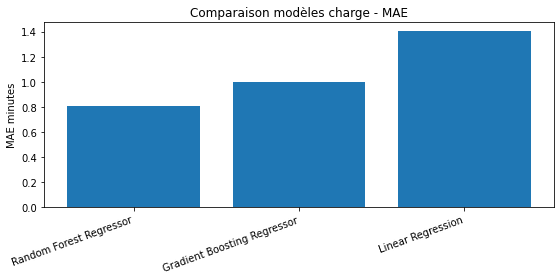

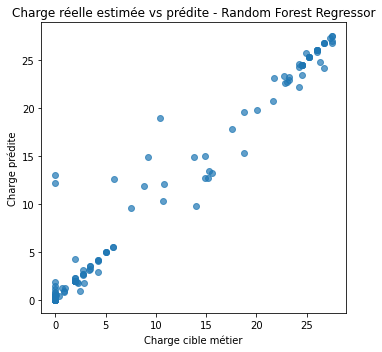

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(charge_results["model"], charge_results["mae"])
plt.title("Comparaison modèles charge - MAE")
plt.ylabel("MAE minutes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

X_test, y_test = charge_test
X_test = X_test[FEATURES].copy()

pred = best_charge_model.predict(X_test)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred, alpha=0.7)
plt.title(f"Charge réelle estimée vs prédite - {best_charge_name}")
plt.xlabel("Charge cible métier")
plt.ylabel("Charge prédite")
plt.tight_layout()
plt.show()

## 9. Module 3 — Comparaison modèles : score d’affectation

In [20]:
# ============================================================
# CORRECTION MODELE AFFECTATION
# A lancer après avoir créé df, X, FEATURES et build_preprocessor()
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import pandas as pd
import joblib

RANDOM_STATE = 42

affectation_models = {
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=8,
        random_state=RANDOM_STATE
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


def compare_affectation_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X[FEATURES].copy(),
        y.copy(),
        test_size=0.25,
        random_state=RANDOM_STATE
    )

    results = []
    fitted = {}

    for name, model in affectation_models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        rmse = math.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "mae": mean_absolute_error(y_test, pred),
            "rmse": rmse,
            "r2": r2_score(y_test, pred)
        })

        fitted[name] = pipe

    res = pd.DataFrame(results).sort_values(
        ["mae", "rmse"],
        ascending=True
    )

    best_name = res.iloc[0]["model"]
    best_model = fitted[best_name]

    return res, best_name, best_model, (X_test.copy(), y_test.copy())


affect_results, best_affect_name, best_affect_model, affect_test = compare_affectation_models(
    X[FEATURES].copy(),
    df["target_affectation_score"].copy()
)

display(affect_results)
print("Meilleur modèle affectation:", best_affect_name)

joblib.dump(
    best_affect_model,
    MODELS_DIR / "best_affectation_model.joblib"
)

print("Modèle affectation sauvegardé :", MODELS_DIR / "best_affectation_model.joblib")

,model,mae,rmse,r2
0,Decision Tree Regressor,0.744233,3.183669,0.988962
1,Random Forest Regressor,0.897587,2.935108,0.990618


Meilleur modèle affectation: Decision Tree Regressor
Modèle affectation sauvegardé : c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\models\best_affectation_model.joblib


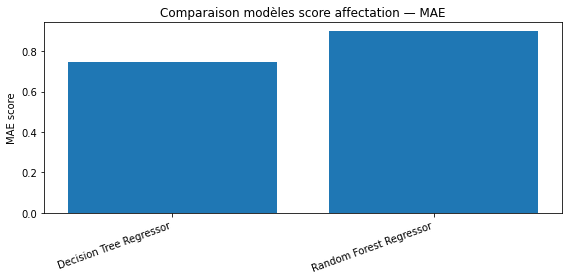

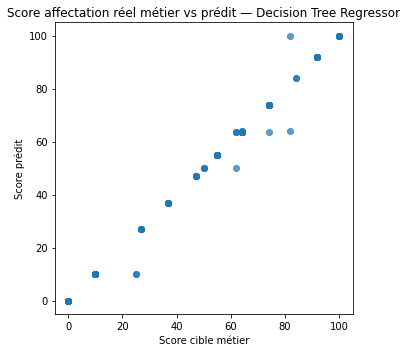

In [21]:
plt.figure(figsize=(8, 4))
plt.bar(affect_results["model"], affect_results["mae"])
plt.title("Comparaison modèles score affectation — MAE")
plt.ylabel("MAE score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

X_test, y_test = affect_test
pred = best_affect_model.predict(X_test)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred, alpha=0.7)
plt.title(f"Score affectation réel métier vs prédit — {best_affect_name}")
plt.xlabel("Score cible métier")
plt.ylabel("Score prédit")
plt.tight_layout()
plt.show()


## 10. Génération des résultats opérationnels CSV

In [22]:
df_predictions = df.copy()

if hasattr(best_retard_model.named_steps["model"], "predict_proba"):
    df_predictions["pred_retard_proba"] = best_retard_model.predict_proba(X)[:, 1]
else:
    df_predictions["pred_retard_proba"] = best_retard_model.predict(X)

df_predictions["pred_retard"] = (df_predictions["pred_retard_proba"] >= 0.5).astype(int)
df_predictions["pred_charge_minutes"] = np.maximum(best_charge_model.predict(X), 0)
df_predictions["pred_affectation_score"] = np.clip(best_affect_model.predict(X), 0, 100)

def risk_label(p):
    if p >= 0.75:
        return "Élevé"
    if p >= 0.45:
        return "Moyen"
    return "Faible"

df_predictions["niveau_risque_retard"] = df_predictions["pred_retard_proba"].apply(risk_label)

retards_out = df_predictions[[
    "id_dossier", "code_client", "client", "position", "statut", "loi_type",
    "etatR", "etatG", "date_livraison_prevue", "jours_restants",
    "pred_retard_proba", "niveau_risque_retard"
]].sort_values("pred_retard_proba", ascending=False)

charge_out = df_predictions[[
    "id_dossier", "code_client", "client", "position", "statut", "loi_type",
    "etatR", "etatG", "page", "jours_restants", "pred_charge_minutes"
]].sort_values("pred_charge_minutes", ascending=False)

affect_out = df_predictions[[
    "id_dossier", "code_client", "client", "position", "statut",
    "redacteur", "graphiste", "teamR", "teamG", "etatR", "etatG",
    "pred_affectation_score"
]].sort_values("pred_affectation_score", ascending=False)

retards_out.to_csv(MODELS_DIR / "prediction_retards_resultats.csv", sep=";", index=False, encoding="utf-8-sig")
charge_out.to_csv(MODELS_DIR / "prediction_charge_future.csv", sep=";", index=False, encoding="utf-8-sig")
affect_out.to_csv(MODELS_DIR / "score_affectation_resultats.csv", sep=";", index=False, encoding="utf-8-sig")
affect_out.head(5).to_csv(MODELS_DIR / "score_affectation_top5.csv", sep=";", index=False, encoding="utf-8-sig")

display(Markdown("### Top risques retard"))
display(retards_out.head(10))

display(Markdown("### Top charges estimées"))
display(charge_out.head(10))

display(Markdown("### Top scores affectation"))
display(affect_out.head(10))


### Top risques retard

,id_dossier,code_client,client,position,statut,loi_type,etatR,etatG,date_livraison_prevue,jours_restants,pred_retard_proba,niveau_risque_retard
412,135468,552684,COMME UNE EVIDENCE 2,Production,En cours,ticket_modification,,En pause,2026-05-20,0.0,0.988514,Élevé
434,135489,618680,MAISON CANITROT,Production,En cours,ticket_modification,Validé,En pause,2026-05-20,0.0,0.982890,Élevé
423,135590,346085,ATOUT BEAUD,Production,En cours,ticket_modification,Validé,En pause,2026-05-20,0.0,0.982059,Élevé
440,135538,619704,DTECH ENERGIES,Production,En cours,ticket_modification,Validé,En pause,2026-05-20,0.0,0.981307,Élevé
425,135594,572887,MARTINE A LA MONTAGNE,Production,En cours,ticket_modification,Validé,En pause,2026-05-20,0.0,0.978293,Élevé
122,135066,626301,BEN CARRELAGE,Production,En cours,production_standard,Validé,En pause,2026-05-21,1.0,0.976280,Élevé
437,135502,502574,BORREL PAYSAGE,Production,En cours,ticket_modification,Validé,En pause,2026-05-20,0.0,0.974806,Élevé
117,135026,622131,MH SELLERIE,Production,En cours,production_standard,Validé,En pause,2026-05-21,1.0,0.974417,Élevé
517,135564,615301,ELEGANCE COVERING,Production,En cours,ticket_modification,Validé,En pause,2026-05-21,1.0,0.972354,Élevé
411,135581,483798,JIDEC,Production,En cours,ticket_modification,,En pause,2026-05-20,0.0,0.972171,Élevé


### Top charges estimées

,id_dossier,code_client,client,position,statut,loi_type,etatR,etatG,page,jours_restants,pred_charge_minutes
196,135455,363744,FRANCE FOTO,Production,En instance,production_standard,En instance,En instance,10,8.0,28.244537
194,135453,624039,M.T.P.A,Production,En instance,production_standard,En instance,En instance,10,8.0,28.242278
200,135459,630616,METAL ART & DESIGN,Production,En instance,production_standard,En instance,En instance,10,8.0,28.242278
214,135484,630564,EURL AXEL DAHLEM,Production,En instance,production_standard,En instance,En instance,10,8.0,28.242278
134,135291,617576,CLIM ENTRETIEN SERVICE,Production,En cours,production_standard,En cours,En instance,10,6.0,28.130719
236,135571,626711,ERIC JARDINAGE,Production,En instance,production_standard,En instance,En instance,9,9.0,27.520000
206,135465,630163,JCP SERVICES,Production,En instance,production_standard,En instance,En instance,9,8.0,27.520000
218,135488,629959,AJH CLEAN,Production,En instance,production_standard,En instance,En instance,9,8.0,27.520000
149,135257,627367,LA FONTAINE AUX FLEURS,Production,En instance,production_standard,En instance,En instance,9,6.0,27.507481
150,135360,626771,DJ FRANCKY MUSIC,Production,En instance,production_standard,En instance,En instance,9,7.0,27.502500


### Top scores affectation

,id_dossier,code_client,client,position,statut,redacteur,graphiste,teamR,teamG,etatR,etatG,pred_affectation_score
270,135408,623538,TOUS SUPPORTS,Production,En cours,RABEI Mouna,Refonte Triweb,SAViX-Up,Genix-Rise 2,En cours,Affecté,100.0
264,135203,615531,AUX DELICES DE NADEGE,Production,En cours,Magri Mohamed,Refonte Triweb,SAViX-Up,Genix-Rise 2,En cours,Affecté,100.0
392,135620,586487,SONO EVENT PRODUCTION,Production,En cours,SEBAI Abir,BEJAOUI Safa,SAViX-Up,Genix-Press,Affecté,Affecté,100.0
393,135623,624167,LN TERASSEMENT,Production,En cours,SEBAI Abir,BEJAOUI Safa,SAViX-Up,Genix-Press,Affecté,Affecté,100.0
394,135625,606295,INTEMPOREL STUDIO,Production,En cours,SEBAI Abir,SAID Rayaa,SAViX-Up,SAViX-Care,Affecté,Affecté,100.0
395,135637,607574,LE SO A OUTILS,Production,En instance,RABEI Mouna,Fezzani Oumaima,SAViX-Up,SAViX- Go,Affecté,Affecté,100.0
396,135642,529059,ALSA-LYS,Production,En cours,Touati Mariem,SAID Rayaa,SAViX-Up,SAViX-Care,Affecté,Affecté,100.0
397,135624,620595,L'AME D'ETRE BIEN,Production,En cours,SEBAI Abir,SAID Rayaa,SAViX-Up,SAViX-Care,En cours,Affecté,100.0
512,135522,482547,PIERROT MULTISERVICES,Production,En instance,Arbi Manel,BEJAOUI Safa,Aur@Nex,Genix-Press,Affecté,Affecté,100.0
390,135597,352136,L'UNIVERS D'EMILIE,Production,En cours,Touati Mariem,BEJAOUI Safa,SAViX-Up,Genix-Press,Affecté,Affecté,100.0


## 11. Case à remplir dans le notebook pour tester une prédiction

In [23]:
# Exemple de dossier à saisir manuellement.
# Modifie les valeurs puis relance la cellule.

input_dossier = {
    "position": "Production",
    "statut": "En cours",
    "loi_type": "production_standard",
    "nature": "Site - LocalVisibilité",
    "etatR": "Validé",
    "etatG": "Affecté",
    "etatCqi": "",
    "etatCqc": "",
    "teamR": "Rédacteur",
    "teamG": "Graphiste",
    "page": 8,
    "charge": 8,
    "totalHours": 8,
    "dureeR_min": 960,
    "dureeG_min": 0,
    "dureeCqi_min": 0,
    "dureeCqc_min": 0,
    "jours_restants": 0
}

input_df = pd.DataFrame([input_dossier])[FEATURES]

retard_prob = float(best_retard_model.predict_proba(input_df)[0, 1])
charge_minutes = float(max(best_charge_model.predict(input_df)[0], 0))
affect_score = float(np.clip(best_affect_model.predict(input_df)[0], 0, 100))

result = {
    "probabilite_retard": round(retard_prob, 3),
    "niveau_risque_retard": risk_label(retard_prob),
    "charge_estimee_minutes": round(charge_minutes, 1),
    "charge_estimee_heures": round(charge_minutes / 60, 2),
    "score_affectation": round(affect_score, 1)
}

display(result)


{'probabilite_retard': 0.028,
 'niveau_risque_retard': 'Faible',
 'charge_estimee_minutes': 20.4,
 'charge_estimee_heures': 0.34,
 'score_affectation': 92.0}

## 12. Déploiement FastAPI professionnel

Cette section génère un dossier `deployment/` avec une API qui charge les meilleurs modèles sauvegardés et expose des endpoints de prédiction.

In [24]:
# Génération des fichiers de déploiement .NET + Angular
# Streamlit n'est pas nécessaire puisque l'interface finale est Angular.

(DEPLOY_DIR / "main.py").write_text('from pathlib import Path\nfrom typing import List\n\nimport joblib\nimport numpy as np\nimport pandas as pd\nfrom fastapi import FastAPI, HTTPException\nfrom pydantic import BaseModel\n\nAPP_DIR = Path(__file__).resolve().parent\n\n# Si main.py est dans backend/AI/ml-api : MODELS_DIR = APP_DIR / "models"\n# Si main.py est dans backend/AI/ml-api/deployment : MODELS_DIR = APP_DIR.parent / "models"\nif (APP_DIR / "models").exists():\n    MODELS_DIR = APP_DIR / "models"\nelse:\n    MODELS_DIR = APP_DIR.parent / "models"\n\nRETARD_MODEL_PATH = MODELS_DIR / "best_retard_model.joblib"\nCHARGE_MODEL_PATH = MODELS_DIR / "best_charge_model.joblib"\nAFFECTATION_MODEL_PATH = MODELS_DIR / "best_affectation_model.joblib"\n\nFEATURES = [\n    "position",\n    "statut",\n    "loi_type",\n    "nature",\n    "etatR",\n    "etatG",\n    "etatCqi",\n    "etatCqc",\n    "teamR",\n    "teamG",\n    "page",\n    "charge",\n    "totalHours",\n    "dureeR_min",\n    "dureeG_min",\n    "dureeCqi_min",\n    "dureeCqc_min",\n    "jours_restants",\n]\n\nmodels = {\n    "retard": None,\n    "charge": None,\n    "affectation": None,\n}\n\napp = FastAPI(\n    title="TriWeb ML API",\n    description="API ML pour prédiction retard, charge restante et score d’affectation.",\n    version="1.0.0",\n)\n\nclass DossierPredictionInput(BaseModel):\n    position: str = "Production"\n    statut: str = "En cours"\n    loi_type: str = "production_standard"\n    nature: str = ""\n\n    etatR: str = ""\n    etatG: str = ""\n    etatCqi: str = ""\n    etatCqc: str = ""\n\n    teamR: str = ""\n    teamG: str = ""\n\n    page: float = 0\n    charge: float = 0\n    totalHours: float = 0\n\n    dureeR_min: float = 0\n    dureeG_min: float = 0\n    dureeCqi_min: float = 0\n    dureeCqc_min: float = 0\n\n    jours_restants: float = 999\n\n@app.on_event("startup")\ndef load_models():\n    print("APP_DIR =", APP_DIR)\n    print("MODELS_DIR =", MODELS_DIR)\n\n    for name, path in {\n        "retard": RETARD_MODEL_PATH,\n        "charge": CHARGE_MODEL_PATH,\n        "affectation": AFFECTATION_MODEL_PATH,\n    }.items():\n        if not path.exists():\n            raise RuntimeError(f"Modèle {name} introuvable : {path}")\n\n    print("Chargement modèle retard...")\n    models["retard"] = joblib.load(RETARD_MODEL_PATH)\n    print("Modèle retard chargé.")\n\n    print("Chargement modèle charge...")\n    models["charge"] = joblib.load(CHARGE_MODEL_PATH)\n    print("Modèle charge chargé.")\n\n    print("Chargement modèle affectation...")\n    models["affectation"] = joblib.load(AFFECTATION_MODEL_PATH)\n    print("Modèle affectation chargé.")\n\ndef to_dataframe(payload: DossierPredictionInput) -> pd.DataFrame:\n    data = payload.dict()\n    df = pd.DataFrame([data])\n\n    for col in FEATURES:\n        if col not in df.columns:\n            df[col] = ""\n\n    return df[FEATURES]\n\ndef risk_label(prob: float) -> str:\n    if prob >= 0.75:\n        return "Élevé"\n    if prob >= 0.45:\n        return "Moyen"\n    return "Faible"\n\ndef affectation_avis(score: float) -> str:\n    if score >= 70:\n        return "Correcte"\n    if score >= 45:\n        return "À surveiller"\n    return "Faible"\n\n@app.get("/")\ndef root():\n    return {\n        "message": "TriWeb ML API",\n        "docs": "/docs",\n        "health": "/health",\n    }\n\n@app.get("/health")\ndef health():\n    return {\n        "status": "ok",\n        "models_dir": str(MODELS_DIR),\n        "files": {\n            "retard": RETARD_MODEL_PATH.exists(),\n            "charge": CHARGE_MODEL_PATH.exists(),\n            "affectation": AFFECTATION_MODEL_PATH.exists(),\n        },\n        "loaded": {\n            "retard": models["retard"] is not None,\n            "charge": models["charge"] is not None,\n            "affectation": models["affectation"] is not None,\n        },\n    }\n\n@app.post("/predict/retard")\ndef predict_retard(payload: DossierPredictionInput):\n    try:\n        df = to_dataframe(payload)\n        model = models["retard"]\n\n        if model is None:\n            raise RuntimeError("Modèle retard non chargé.")\n\n        if hasattr(model.named_steps["model"], "predict_proba"):\n            prob = float(model.predict_proba(df)[0, 1])\n        else:\n            prob = float(model.predict(df)[0])\n\n        return {\n            "prob_retard": round(prob, 4),\n            "niveau_risque_retard": risk_label(prob),\n        }\n\n    except Exception as ex:\n        raise HTTPException(status_code=500, detail=str(ex))\n\n@app.post("/predict/charge")\ndef predict_charge(payload: DossierPredictionInput):\n    try:\n        df = to_dataframe(payload)\n        model = models["charge"]\n\n        if model is None:\n            raise RuntimeError("Modèle charge non chargé.")\n\n        minutes = float(max(model.predict(df)[0], 0))\n\n        return {\n            "charge_estimee_minutes": round(minutes, 2),\n            "charge_estimee_heures": round(minutes / 60, 2),\n        }\n\n    except Exception as ex:\n        raise HTTPException(status_code=500, detail=str(ex))\n\n@app.post("/predict/affectation")\ndef predict_affectation(payload: DossierPredictionInput):\n    try:\n        df = to_dataframe(payload)\n        model = models["affectation"]\n\n        if model is None:\n            raise RuntimeError("Modèle affectation non chargé.")\n\n        score = float(np.clip(model.predict(df)[0], 0, 100))\n\n        return {\n            "score_affectation": round(score, 2),\n            "avis": affectation_avis(score),\n        }\n\n    except Exception as ex:\n        raise HTTPException(status_code=500, detail=str(ex))\n\n@app.post("/predict/all")\ndef predict_all(payload: DossierPredictionInput):\n    try:\n        df = to_dataframe(payload)\n\n        retard_model = models["retard"]\n        charge_model = models["charge"]\n        affectation_model = models["affectation"]\n\n        if retard_model is None or charge_model is None or affectation_model is None:\n            raise RuntimeError("Un ou plusieurs modèles ne sont pas chargés.")\n\n        if hasattr(retard_model.named_steps["model"], "predict_proba"):\n            prob = float(retard_model.predict_proba(df)[0, 1])\n        else:\n            prob = float(retard_model.predict(df)[0])\n\n        minutes = float(max(charge_model.predict(df)[0], 0))\n        score = float(np.clip(affectation_model.predict(df)[0], 0, 100))\n\n        return {\n            "retard": {\n                "prob_retard": round(prob, 4),\n                "niveau_risque_retard": risk_label(prob),\n            },\n            "charge": {\n                "charge_estimee_minutes": round(minutes, 2),\n                "charge_estimee_heures": round(minutes / 60, 2),\n            },\n            "affectation": {\n                "score_affectation": round(score, 2),\n                "avis": affectation_avis(score),\n            },\n        }\n\n    except Exception as ex:\n        raise HTTPException(status_code=500, detail=str(ex))\n\n@app.post("/predict/batch")\ndef predict_batch(payloads: List[DossierPredictionInput]):\n    return [predict_all(payload) for payload in payloads]\n', encoding="utf-8")
(DEPLOY_DIR / "requirements.txt").write_text('fastapi\nuvicorn\npandas\nnumpy\njoblib\nscikit-learn==1.3.2\npydantic\nrequests\n', encoding="utf-8")
(DEPLOY_DIR / "README.md").write_text('# TriWeb ML API — Déploiement .NET + Angular\n\n## 1. Exécuter le notebook\nExécuter toutes les cellules jusqu’à la génération des modèles.\n\nFichiers attendus :\n- `models/best_retard_model.joblib`\n- `models/best_charge_model.joblib`\n- `models/best_affectation_model.joblib`\n\n## 2. Installer les dépendances\n\nDepuis `backend/AI/ml-api` :\n\n```bash\npip install -r deployment/requirements.txt\n```\n\nou si `requirements.txt` est à la racine `ml-api` :\n\n```bash\npip install -r requirements.txt\n```\n\n## 3. Lancer FastAPI\n\nDepuis `backend/AI/ml-api` :\n\n```bash\nuvicorn deployment.main:app --host 127.0.0.1 --port 8000\n```\n\nou si `main.py` est à la racine `ml-api` :\n\n```bash\nuvicorn main:app --host 127.0.0.1 --port 8000\n```\n\n## 4. Tester\n\n- http://127.0.0.1:8000/\n- http://127.0.0.1:8000/health\n- http://127.0.0.1:8000/docs\n\n## 5. Intégration\nAngular appelle .NET :\n- `http://localhost:5000/api/ml-models/predict/all`\n\n.NET appelle FastAPI :\n- `http://127.0.0.1:8000/predict/all`\n', encoding="utf-8")

print("Fichiers générés dans:", DEPLOY_DIR)
print("- main.py")
print("- requirements.txt")
print("- README.md")
print()
print("Commande depuis backend/AI/ml-api :")
print("pip install -r deployment/requirements.txt")
print("uvicorn deployment.main:app --host 127.0.0.1 --port 8000")


Fichiers générés dans: c:\Users\marie\Downloads\triweb1\triweb\backend\AI\ml-api\deployment
- main.py
- requirements.txt
- README.md

Commande depuis backend/AI/ml-api :
pip install -r deployment/requirements.txt
uvicorn deployment.main:app --host 127.0.0.1 --port 8000


## 13. Commandes de lancement

In [25]:
print("""
# Depuis le dossier du notebook :

pip install -r deployment/requirements.txt

# Lancer l’API :
uvicorn deployment.main:app --reload --host 0.0.0.0 --port 8000

# Documentation API :
http://localhost:8000/docs

# Lancer l’interface à champs :
streamlit run deployment/streamlit_app.py
""")



# Depuis le dossier du notebook :

pip install -r deployment/requirements.txt

# Lancer l’API :
uvicorn deployment.main:app --reload --host 0.0.0.0 --port 8000

# Documentation API :
http://localhost:8000/docs

# Lancer l’interface à champs :
streamlit run deployment/streamlit_app.py



## 14. Résumé présentation

- **Prédiction des retards** : comparaison Logistic Regression, Random Forest et Gradient Boosting, puis déploiement du meilleur modèle.
- **Estimation de surcharge** : comparaison Linear Regression, Random Forest Regressor et Gradient Boosting Regressor, puis déploiement du meilleur modèle.
- **Score d’affectation** : comparaison Decision Tree, Random Forest et Gradient Boosting, puis déploiement du meilleur modèle.

Le déploiement se fait avec :
- API FastAPI pour intégration backend / Angular.
- Interface Streamlit pour tester avec des champs à remplir.
- Fichiers `.joblib` pour sauvegarder les meilleurs modèles.
